# Heart Disease Prediction System
## Exploratory Data Analysis and Preprocessing Notebook

Project:
Heart Disease Prediction System using End-to-End Machine Learning Pipeline

Dataset:
Heart Disease Dataset (Kaggle)

Objectives:
- Understand dataset characteristics
- Validate data quality
- Perform exploratory data analysis
- Prepare dataset for machine learning
- Generate reproducible preprocessing workflow
- Produce processed datasets for model training

## Cell 2 (Import Libraries)

python3 -m venv .venv  
source .venv/bin/activate

pip install -U numpy pandas matplotlib seaborn scipy scikit-learn joblib jupyter notebook

pip freeze > requirements.txt

pip install -r requirements.txt

In [1]:
import sys
print(sys.executable)
print(sys.version)

/home/lazy4u/Projects/Eksperimen_SML/.venv/bin/python
3.14.4 (main, Apr  8 2026, 04:02:31) [GCC 15.2.0]


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import joblib

## Cell 3 (Configuration)

In [3]:
RANDOM_STATE = 42

TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Cell 4 (Directory Configuration)

In [4]:
from pathlib import Path

ROOT = Path.cwd().parent
RAW_DATA_PATH = ROOT / "data/raw/heart.csv"

INTERIM_DIR = ROOT / "data/interim"
PROCESSED_DIR = ROOT / "data/processed"
REPORT_DIR = ROOT / "reports"
ARTIFACT_DIR = ROOT /"artifacts"

os.makedirs(INTERIM_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

## Cell 5 (Data Loading)

In [5]:
df = pd.read_csv(RAW_DATA_PATH)

original_df = df.copy()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Cell 6 (Initial Exploration)

In [6]:
df.info()
df.describe().T
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
527,62,0,0,124,209,0,1,163,0,0.0,2,0,2,1
359,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1
447,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
621,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0


## Cell 7 (Data Validation)

In [7]:
expected_columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

missing_columns = set(expected_columns) - set(df.columns)
additional_columns = set(df.columns) - set(expected_columns)

validation_report = {
    "dataset_shape": df.shape,
    "missing_columns": list(missing_columns),
    "additional_columns": list(additional_columns),
    "duplicate_columns": int(df.columns.duplicated().sum())
}

validation_report

with open(
    f"{REPORT_DIR}/data_validation.json",
    "w"
) as f:
    json.dump(validation_report, f, indent=4)

assert len(missing_columns)==0
assert df.shape[0] > 0

## Cell 8 (Missing Value Analysis)

In [8]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().sum()/len(df)
    )*100
})

missing.sort_values(
    by="missing_count",
    ascending=False
)

missing.to_json(
    f"{REPORT_DIR}/missing_value_report.json",
    indent=4
)

## Cell 9 (Duplicate Analysis)

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

duplicate_report = {
    "duplicate_rows": int(duplicates)
}

with open(
    f"{REPORT_DIR}/duplicate_report.json",
    "w"
) as f:
    json.dump(
        duplicate_report,
        f,
        indent=4
    )

df = df.drop_duplicates()

print(df.shape)

Duplicate rows: 723
(302, 14)


## Cell 10 (Univariate Analysis)

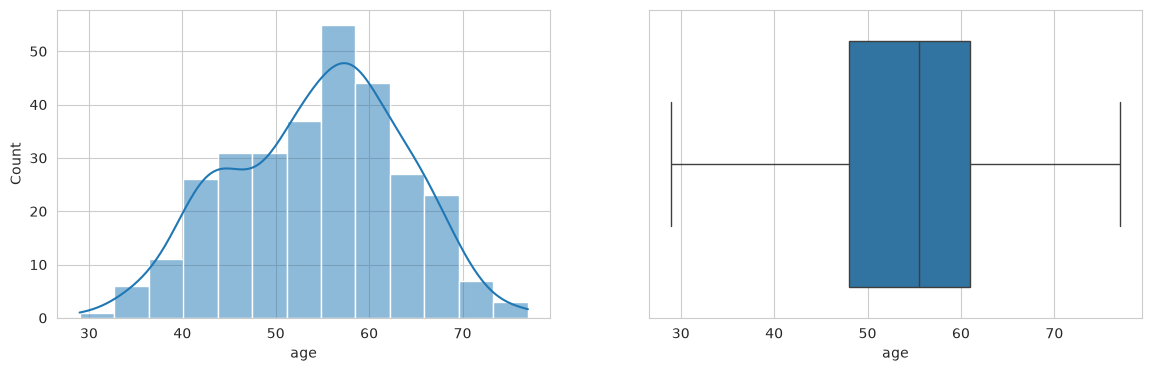

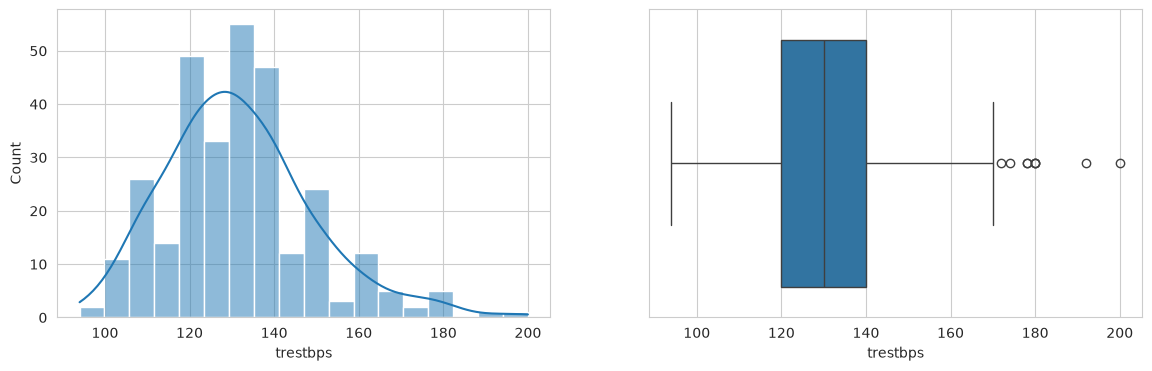

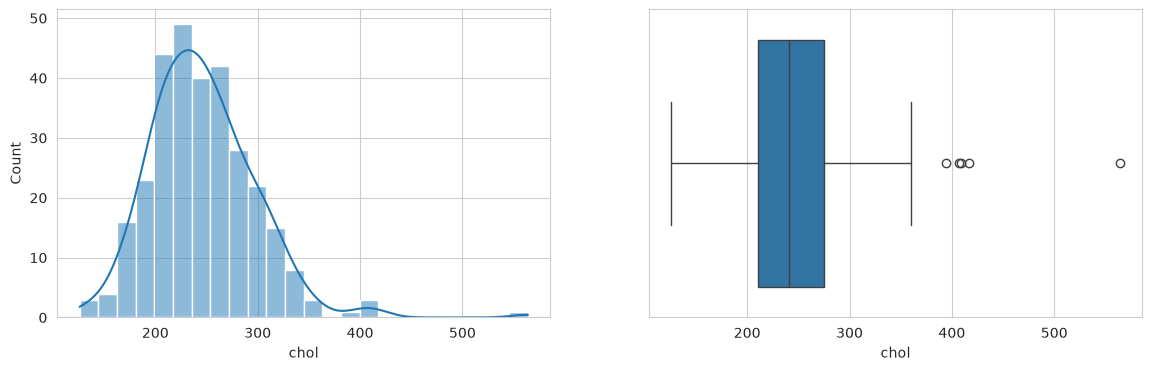

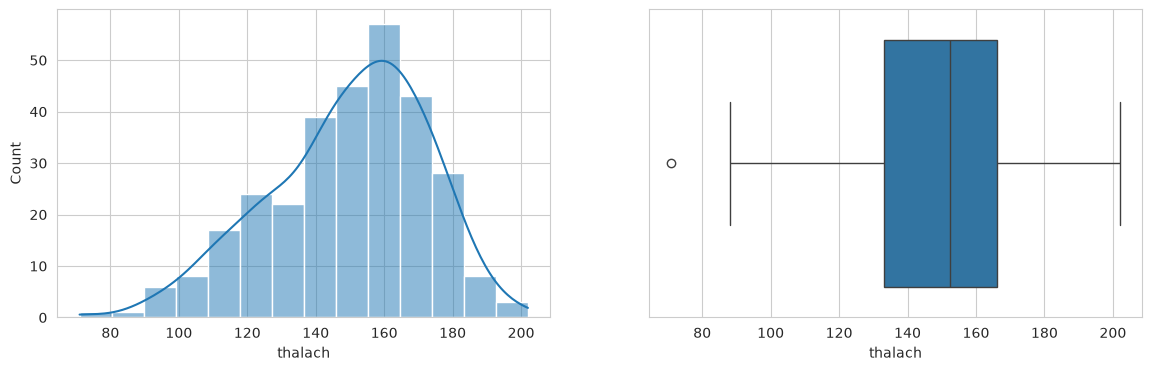

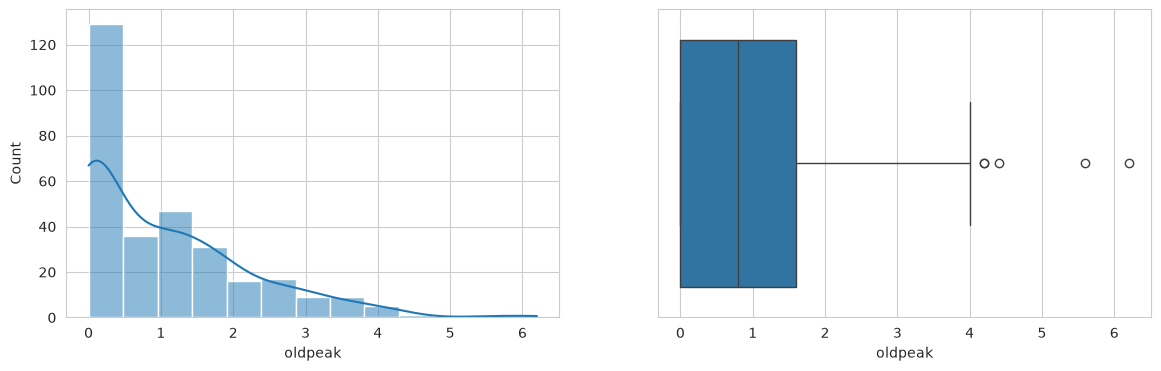

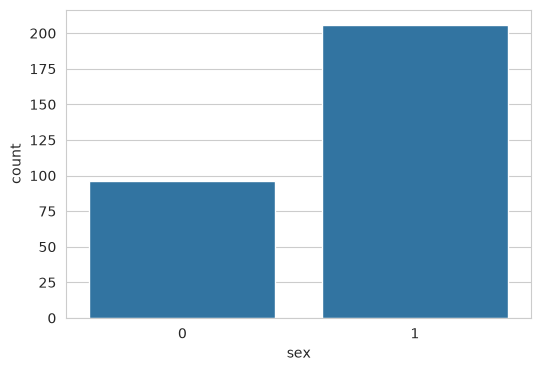

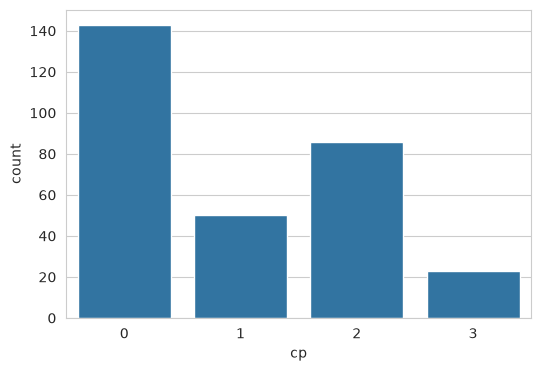

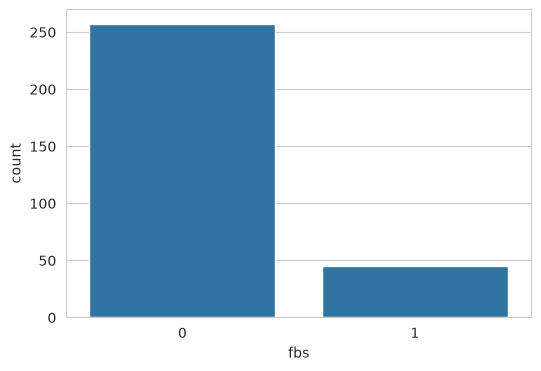

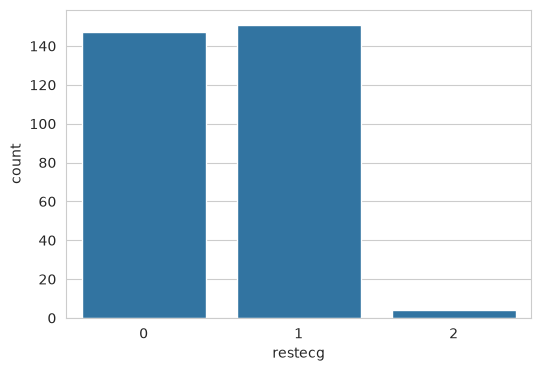

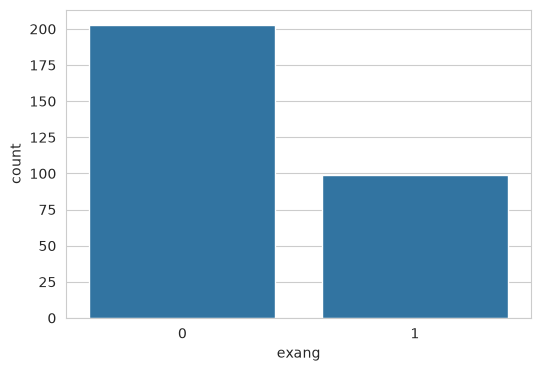

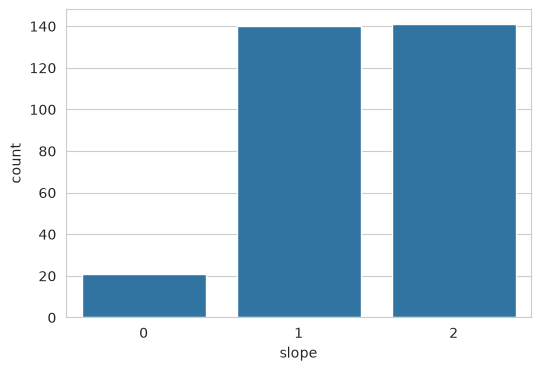

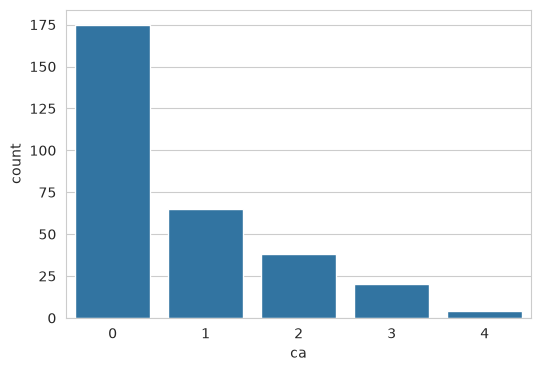

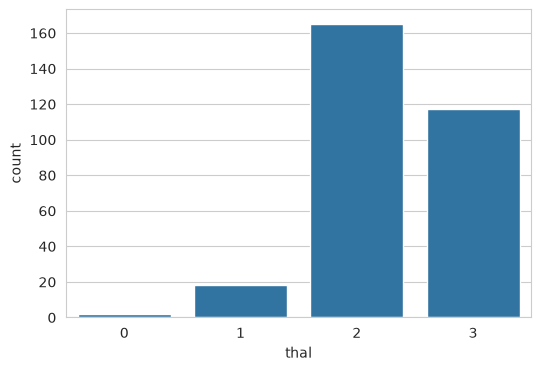

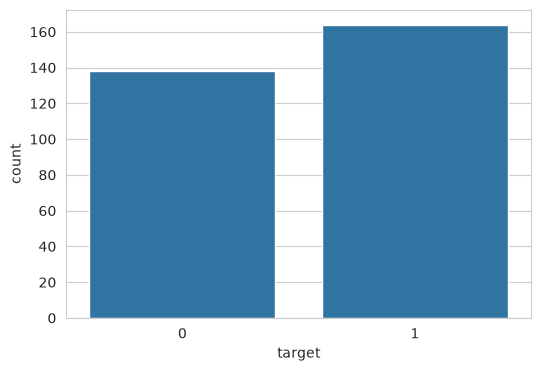

In [10]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for col in numerical_features:
    fig, ax = plt.subplots(
        1,
        2,
        figsize=(14,4)
    )

    sns.histplot(
        df[col],
        kde=True,
        ax=ax[0]
    )

    sns.boxplot(
        x=df[col],
        ax=ax[1]
    )

    plt.show()

# categorial

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    "target"
]

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(
        data=df,
        x=col
    )
    plt.show()

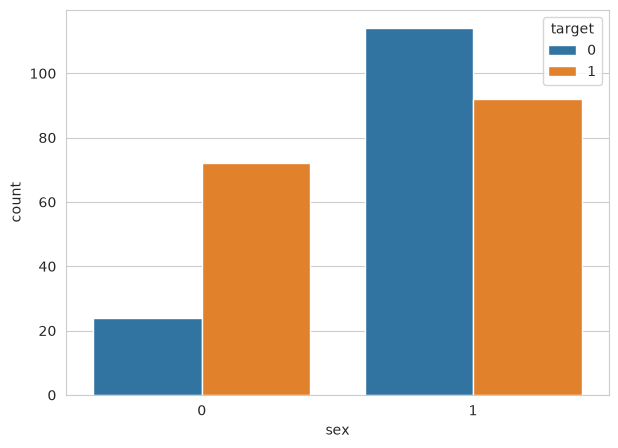

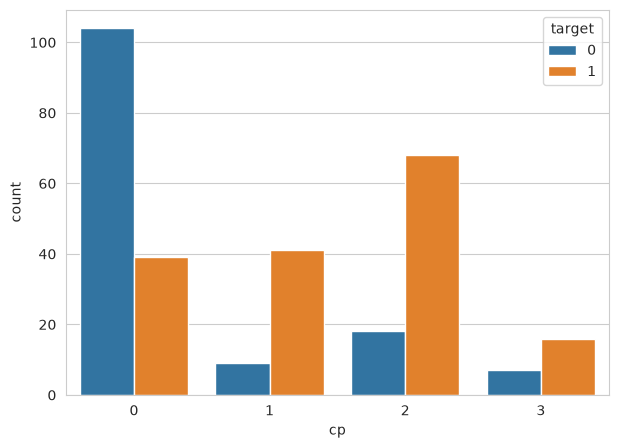

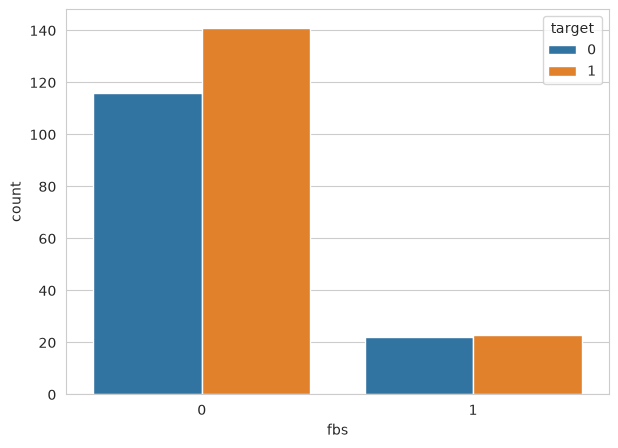

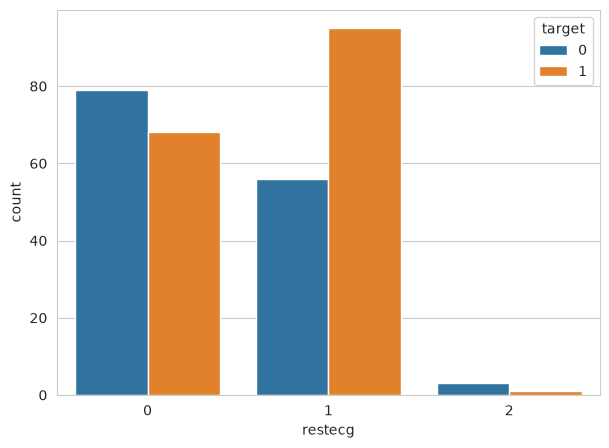

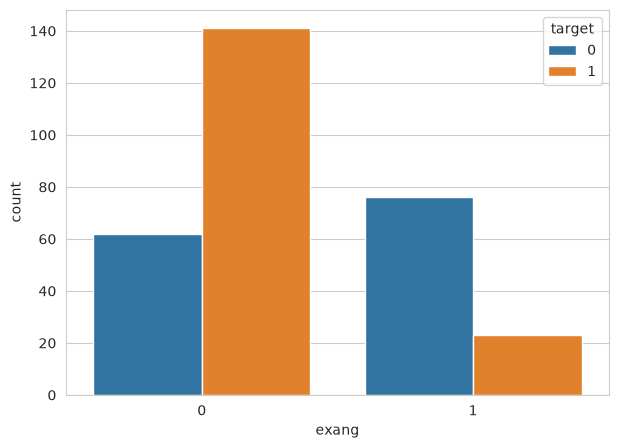

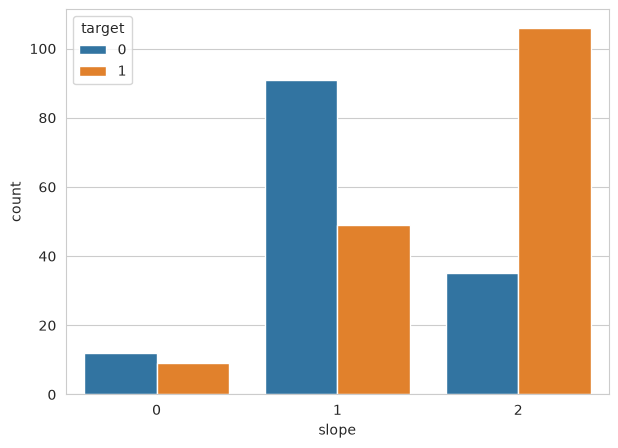

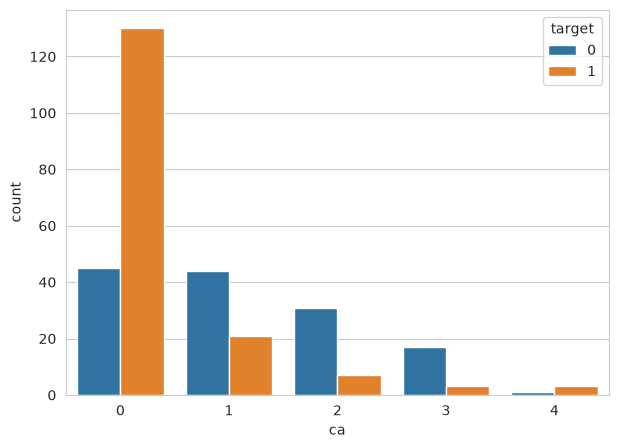

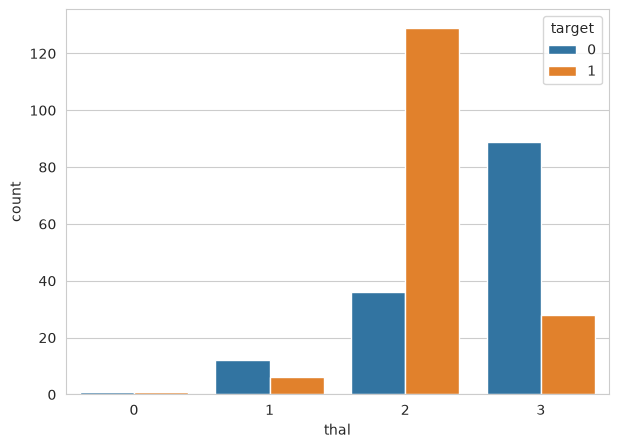

In [11]:
for col in categorical_features[:-1]:
    plt.figure(figsize=(7,5))

    sns.countplot(
        data=df,
        x=col,
        hue="target"
    )

    plt.show()

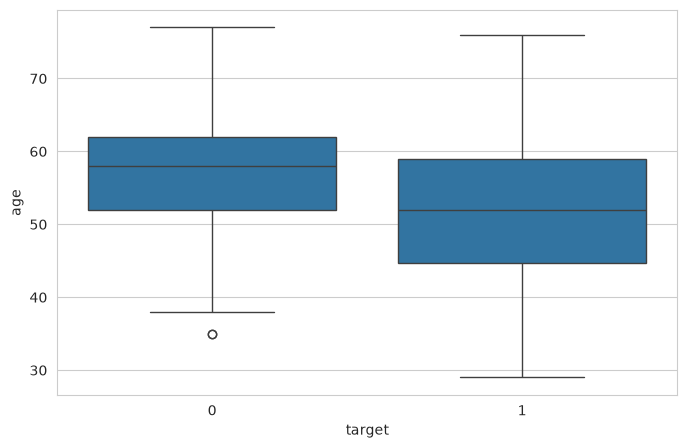

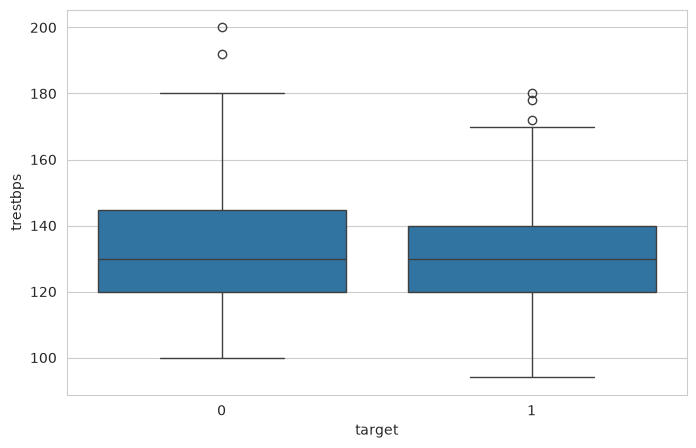

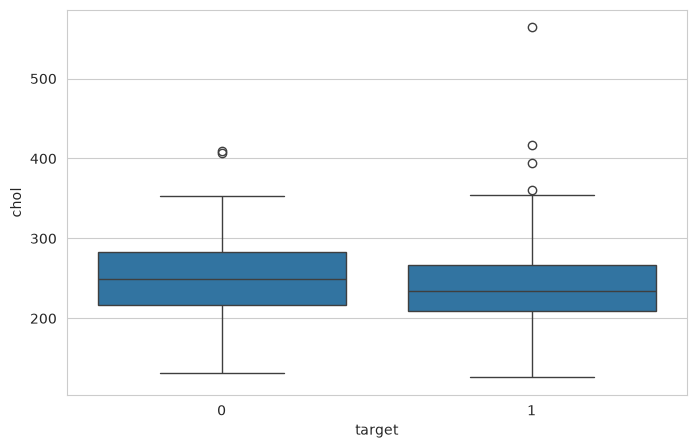

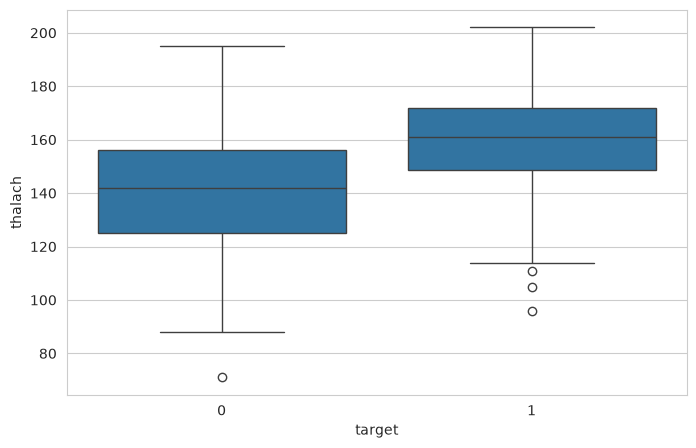

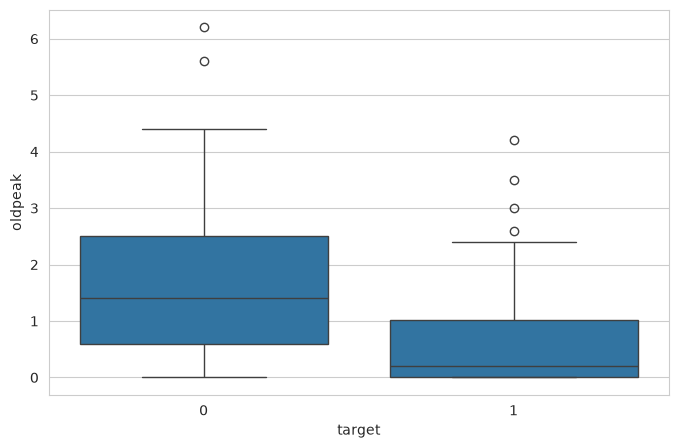

In [12]:
for col in numerical_features:
    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="target",
        y=col
    )

    plt.show()

In [13]:
outlier_report = {}

for col in numerical_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower)
        |
        (df[col] > upper)
    ]

    outlier_report[col] = len(outliers)

pd.DataFrame.from_dict(
    outlier_report,
    orient="index",
    columns=["outliers"]
)

,outliers
age,0
trestbps,9
chol,5
thalach,1
oldpeak,5


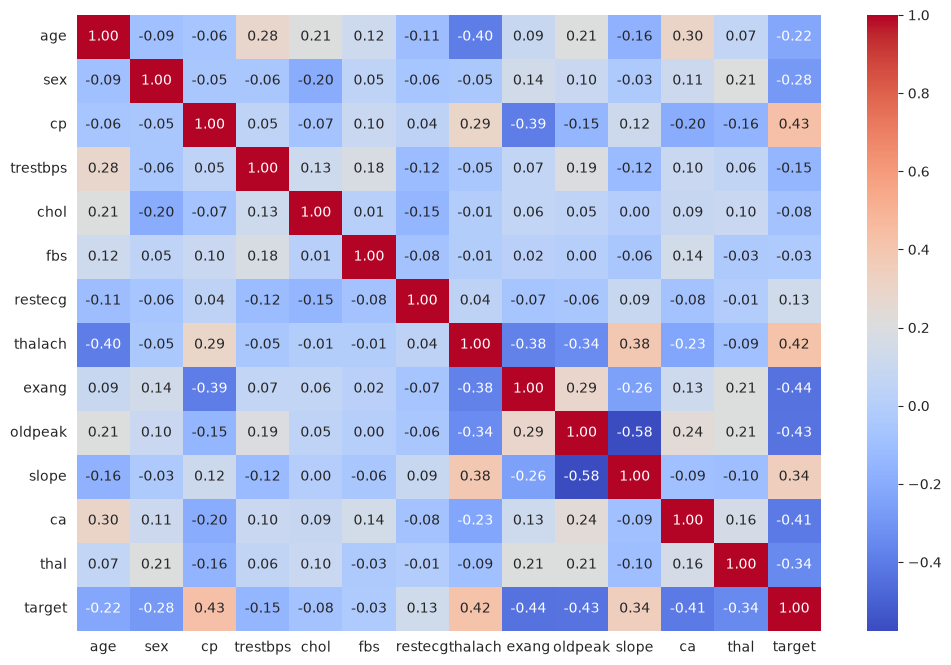

In [14]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [15]:
# df["age_group"] = pd.cut(
#     df["age"],
#     bins=[0,40,55,100],
#     labels=[
#         "young",
#         "middle",
#         "old"
#     ]
# )

# Feature engineering is not applied
# because no significant performance improvement
# is expected for this dataset.

In [16]:
X = df.drop("target", axis=1)
y = df["target"]

categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [17]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_columns
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

In [19]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

X_test_processed = preprocessor.transform(
    X_test
)

In [20]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_val_processed = pd.DataFrame(
    X_val_processed,
    columns=feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

In [21]:
X_train_processed.to_csv(
    PROCESSED_DIR / "X_train.csv", 
    index=False
)

X_val_processed.to_csv(
    PROCESSED_DIR / "X_val.csv",
    index=False
)

X_test_processed.to_csv(
    PROCESSED_DIR / "X_test.csv",
    index=False
)

y_train.to_csv(
    PROCESSED_DIR / "y_train.csv",
    index=False
)

y_val.to_csv(
    PROCESSED_DIR / "y_val.csv",
    index=False
)

y_test.to_csv(
    PROCESSED_DIR / "y_test.csv",
    index=False
)

In [22]:
df.to_csv(
    f"{INTERIM_DIR}/heart_cleaned.csv",
    index=False
)

In [23]:
joblib.dump(
    preprocessor,
    f"{ARTIFACT_DIR}/preprocessor.pkl"
)

summary = {
    "original_shape": df.shape,
    "train_shape": X_train_processed.shape,
    "validation_shape": X_val_processed.shape,
    "test_shape": X_test_processed.shape,
    "duplicate_removed": duplicates,
    "missing_values": int(df.isnull().sum().sum())
}

summary

{'original_shape': (302, 14),
 'train_shape': (211, 30),
 'validation_shape': (45, 30),
 'test_shape': (46, 30),
 'duplicate_removed': np.int64(723),
 'missing_values': 0}

In [24]:
print("Train :", X_train_processed.shape)
print("Validation :", X_val_processed.shape)
print("Test :", X_test_processed.shape)

Train : (211, 30)
Validation : (45, 30)
Test : (46, 30)


In [25]:
preprocessing_summary = {
    "original_rows": int(original_df.shape[0]),
    "processed_rows": int(df.shape[0]),
    "duplicates_removed": int(duplicates),
    "missing_values": int(df.isnull().sum().sum()),
    "train_shape": list(X_train_processed.shape),
    "validation_shape": list(X_val_processed.shape),
    "test_shape": list(X_test_processed.shape),
    "random_state": RANDOM_STATE
}

with open(REPORT_DIR / "preprocessing_report.json", "w") as f:
    json.dump(preprocessing_summary, f, indent=4)

preprocessing_summary

{'original_rows': 1025,
 'processed_rows': 302,
 'duplicates_removed': 723,
 'missing_values': 0,
 'train_shape': [211, 30],
 'validation_shape': [45, 30],
 'test_shape': [46, 30],
 'random_state': 42}

# Conclusions

1. Dataset contains 1025 observations and 13 features.
2. Duplicate records were removed.
3. Missing values are minimal/non-existent.
4. Several numerical variables contain outliers but remain medically meaningful.
5. Data preprocessing pipeline has been created successfully.
6. Processed datasets and preprocessing artifacts have been generated.
7. The dataset is ready for the modelling phase.